### 1. 데이터 준비

In [228]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/Life-Expectancy-Data-Updated.csv')

df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


In [229]:
# 전처리
# Economoy_status_developed랑 economoy_status_devolping은 굳이 다른 열일 필요가 없음
# 하나로 통합. (Developed = 1,Ddeveloping=0)
# 그 외에 이상치, 결측치가 없는건 윤우님 노트북을 통해 확인.
df['Economy_status'] = df['Economy_status_Developed']
df = df.drop('Economy_status_Developed', axis=1)
df = df.drop('Economy_status_Developing', axis=1)
df

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Life_expectancy,Economy_status
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.320,97,65,27.8,97,97,0.08,11006,78.53,4.9,4.8,7.8,76.5,0
1,Spain,European Union,2015,2.7,3.3,57.9025,10.350,97,94,26.0,97,97,0.09,25742,46.44,0.6,0.5,9.7,82.8,1
2,India,Asia,2007,51.5,67.9,201.0765,1.570,60,35,21.2,67,64,0.13,1076,1183.21,27.1,28.0,5.0,65.4,0
3,Guyana,South America,2006,32.8,40.5,222.1965,5.680,93,74,25.3,92,93,0.79,4146,0.75,5.7,5.5,7.9,67.0,0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.890,97,89,27.0,94,94,0.08,33995,7.91,1.2,1.1,12.8,81.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,Niger,Africa,2000,97.0,224.9,291.8240,0.092,72,64,20.8,41,34,0.49,399,11.33,12.8,12.9,1.1,49.9,0
2860,Mongolia,Asia,2009,23.9,28.6,235.2330,6.560,97,97,25.3,96,95,0.02,2515,2.67,2.2,2.3,9.1,66.9,0
2861,Sri Lanka,Asia,2004,17.7,28.9,134.8950,1.560,62,95,21.9,97,97,0.02,2130,19.39,15.4,15.5,10.3,74.3,0
2862,Lithuania,European Union,2002,7.9,9.9,204.0120,11.000,94,95,26.1,97,95,0.05,7424,3.44,3.3,3.3,11.1,71.8,1


### 2. 전체 개요 확인

#### 2.1 기대수명 분포 확인

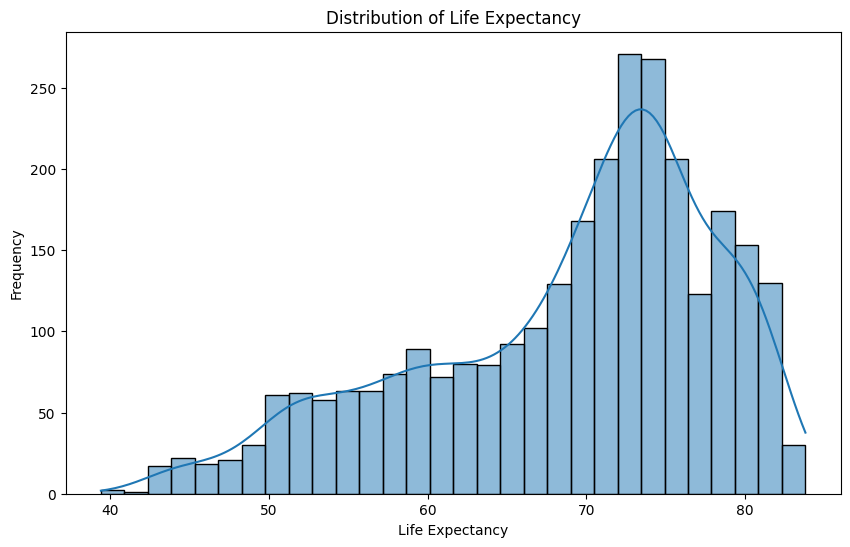

count    2864.000000
mean       68.856075
std         9.405608
min        39.400000
25%        62.700000
50%        71.400000
75%        75.400000
max        83.800000
Name: Life_expectancy, dtype: float64


In [230]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Life_expectancy'], kde=True, bins=30)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.show()

# 기대수명의 기술 통계량
print(df['Life_expectancy'].describe())

#### 2.2 경제 상태별 기대수명 차이 확인

C:\Users\0124m\AppData\Local\Temp\ipykernel_21204\1222088956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Economy_status', y='Life_expectancy', palette='pastel')


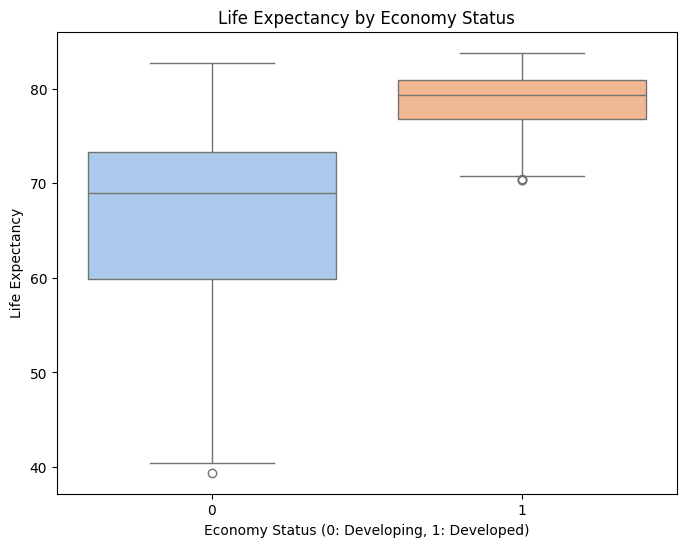

                 count       mean       std   min   25%   50%   75%   max
Economy_status                                                           
0               2272.0  66.341725  8.850451  39.4  59.9  69.0  73.3  82.7
1                592.0  78.505743  3.159564  70.3  76.8  79.3  80.9  83.8


In [231]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Economy_status', y='Life_expectancy', palette='pastel')
plt.title('Life Expectancy by Economy Status')
plt.xlabel('Economy Status (0: Developing, 1: Developed)')
plt.ylabel('Life Expectancy')
plt.show()

# 각 경제 상태별 기대수명 통계량 확인
print(df.groupby('Economy_status')['Life_expectancy'].describe())

### 3. 통합 상관관계 분석 (Correlation Analysis)

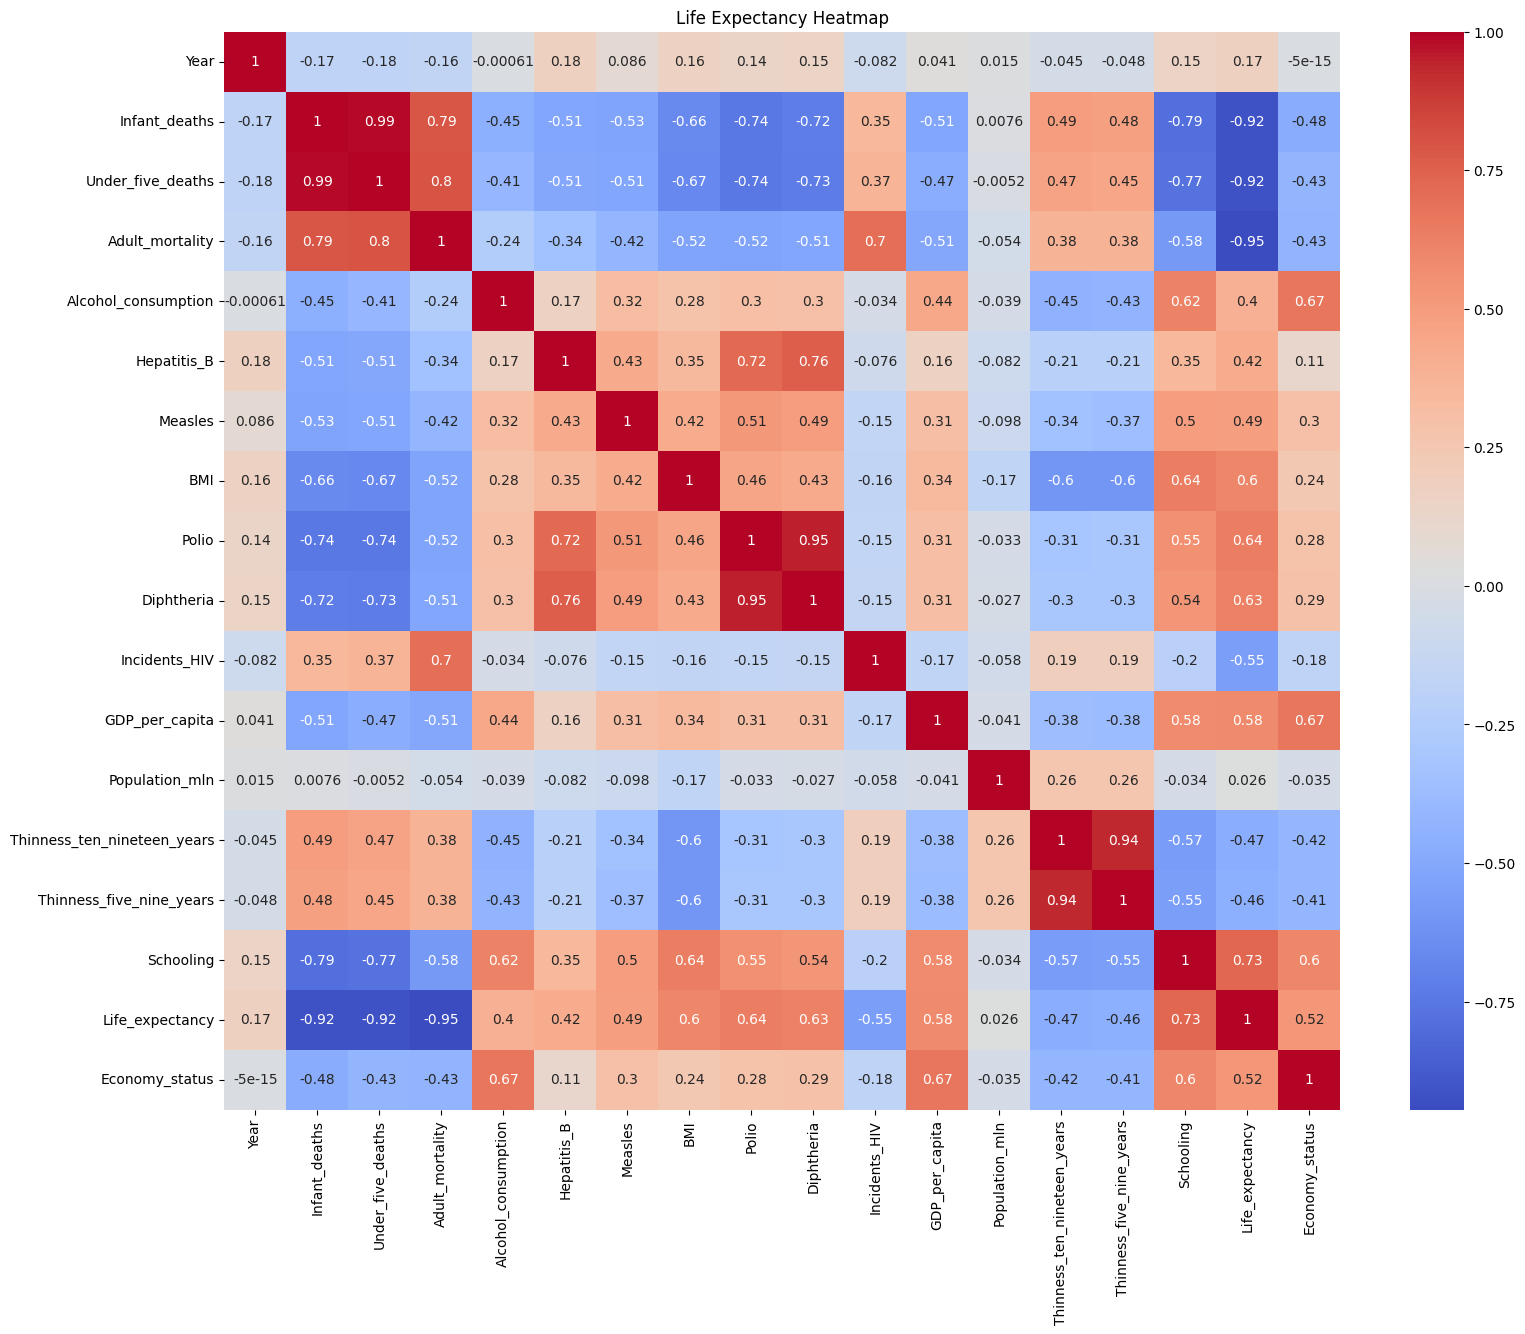

Life_expectancy                1.000000
Schooling                      0.732484
Polio                          0.641217
Diphtheria                     0.627541
BMI                            0.598423
GDP_per_capita                 0.583090
Economy_status                 0.523791
Measles                        0.490019
Hepatitis_B                    0.417804
Alcohol_consumption            0.399159
Year                           0.174359
Population_mln                 0.026298
Thinness_five_nine_years      -0.458166
Thinness_ten_nineteen_years   -0.467824
Incidents_HIV                 -0.553027
Infant_deaths                 -0.920032
Under_five_deaths             -0.920419
Adult_mortality               -0.945360
Name: Life_expectancy, dtype: float64


In [242]:
correlation_matrix = df.corr(numeric_only=True)

# 상관관계 히트맵 시각화
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Life Expectancy Heatmap')
plt.show()


# 기대수명과의 상관관계를 내림차순 정렬
life_expectancy_corr = correlation_matrix['Life_expectancy'].sort_values(ascending=False)
print(life_expectancy_corr)

궁금증: 왜 schooling과 가장 높은 양의 상관관계를 갖는지?  
-> 사회, 경제적 요인이 어쩌면 기대수명에 더 큰 영향을 주나?

### 4. 주요 요인별 심층 분석
상관관계 분석 결과를 바탕으로, 변수들을 아래의 4가지 기준으로 재분류하여 심층 분석을 진행함  
연도와 지역별로 나누어서 보는게 아니라 이러한 요인들이 갖추어진 상황에서 기대수명이 어떻게 바뀌는지 보이고자 함  
단, 비약이 존재하기 때문에 주의할 필요가 있음.

- **그룹 1: 사회경제적 요인**: `Schooling`, `GDP_per_capita`, `Economy_status`
- **그룹 2: 생활/영양 요인**: `Alcohol_consumption`, `BMI`, `Thinness_ten_nineteen_years`, `Thinness_five_nine_years`
- **그룹 3: 질병 및 예방접종 요인**: `Incidents_HIV`, `Hepatitis_B`, `Polio`, `Diphtheria`, `Measles`
- **그룹 4: 보건 결과 지표**: `Adult_mortality`, `Infant_deaths`, `Under_five_deaths`


PCA를 이용해서 각 그룹의 요소들을 대표하는 종합 점수(종합 변수)를 만들어 시각화해 봄

##### 상관관계 양수로 통일
- 나중에 종합점수로 영향력을 계산할 때 어느거는 양수고, 어느거는 음수로 나오면 골치 아플거 같음

In [233]:
# 음의 상관관계를 갖는 지표들 리스트
negative_indicators = [
    'Thinness_five_nine_years', 'Thinness_ten_nineteen_years', 'Incidents_HIV', 
    'Infant_deaths', 'Under_five_deaths', 'Adult_mortality', 
]

df_positive = df.copy()

# 방향 반전 및 컬럼명 변경
for col in negative_indicators:
    new_col_name = col + '_Reversed'
    df_positive[new_col_name] = -df[col]
    df.drop(col, axis=1)
    print(f"변환 완료: {col} -> {new_col_name}")

# 3. 이제 긍정 지표들만 모아서 그룹핑 진행
health_outcome_factors = ['Infant_Survival', 'Under_Five_Survival', 'Adult_Survival']
# 예: 영양/생활 종합 점수
nutritional_factors = ['BMI', 'Alcohol_Control_Score', 'Nutritional_Status_10_19', 'Nutritional_Status_5_9']

변환 완료: Thinness_five_nine_years -> Thinness_five_nine_years_Reversed
변환 완료: Thinness_ten_nineteen_years -> Thinness_ten_nineteen_years_Reversed
변환 완료: Incidents_HIV -> Incidents_HIV_Reversed
변환 완료: Infant_deaths -> Infant_deaths_Reversed
변환 완료: Under_five_deaths -> Under_five_deaths_Reversed
변환 완료: Adult_mortality -> Adult_mortality_Reversed


In [ ]:
# Standardization 먼저
# 각 column에 따라 값의 범위가 너무 다르기 때문에 scaling을 통해 통일 시켜주고 pca를 계산
from sklearn.preprocessing import StandardScaler

# 숫자 feature들
feature_cols = df_positive.drop(['Country', 'Region'], axis=1).columns
df_features = df_positive[feature_cols]

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=feature_cols)

df_scaled['Life_expectancy'] = df_positive['Life_expectancy']

df_scaled.head()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,...,Thinness_five_nine_years,Schooling,Life_expectancy,Economy_status,Thinness_five_nine_years_Reversed,Thinness_ten_nineteen_years_Reversed,Incidents_HIV_Reversed,Infant_deaths_Reversed,Under_five_deaths_Reversed,Adult_mortality_Reversed
0,1.626978,-0.699654,-0.671831,-0.752264,-0.879342,0.794574,-0.661700,1.261475,0.696414,0.690747,...,-0.022064,0.052941,76.5,-0.510454,0.022064,-0.007695,0.341998,0.699654,0.671831,0.752264
1,1.626978,-1.004739,-0.889504,-1.169371,1.388788,0.794574,0.892723,0.440877,0.696414,0.690747,...,-0.972460,0.652121,82.8,1.959040,0.972460,0.961328,0.337798,1.004739,0.889504,1.169371
2,-0.108465,0.767660,0.560155,0.076810,-0.816547,-1.518979,-2.269725,-1.747384,-1.293275,-1.433965,...,5.105658,-0.830060,65.4,-0.510454,-5.105658,-5.010559,0.320998,-0.767660,-0.560155,-0.076810
3,-0.325396,0.088482,-0.054716,0.260638,0.215791,0.544460,-0.179293,0.121756,0.364800,0.433206,...,0.132652,0.084477,67.0,-0.510454,-0.132652,-0.187979,0.043800,-0.088482,0.054716,-0.260638
4,0.976187,-0.979315,-0.867064,-1.168949,-0.484993,0.794574,0.624719,0.896765,0.497445,0.497592,...,-0.839847,1.629730,81.7,1.959040,0.839847,0.826115,0.341998,0.979315,0.867064,1.168949


#### 4.1 사회경제적 요인

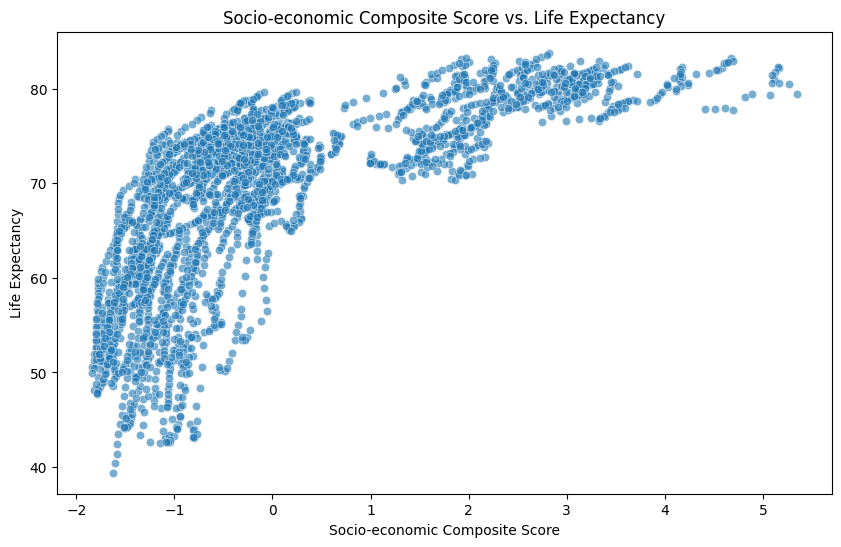

사회경제적 종합 점수와 기대수명과의 상관관계: 0.7084898528366519
설명력: 0.74
[[0.56064416 0.58274241 0.58829364]]


In [235]:
from sklearn.decomposition import PCA

socio_economic_factors = ['Schooling', 'GDP_per_capita', 'Economy_status']
df_socio_economic = df_scaled[socio_economic_factors]

# PCA 실행
pca_socio_economic = PCA(n_components=1)
socio_economic_score = pca_socio_economic.fit_transform(df_socio_economic)

df_scaled['SocioEconomic_Composite'] = socio_economic_score

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled['SocioEconomic_Composite'], y=df_scaled['Life_expectancy'], alpha=0.6)
plt.title('Socio-economic Composite Score vs. Life Expectancy')
plt.xlabel('Socio-economic Composite Score')
plt.ylabel('Life Expectancy')
plt.show()

print(f"사회경제적 종합 점수와 기대수명과의 상관관계: {df_scaled['SocioEconomic_Composite'].corr(df_scaled['Life_expectancy'])}")
print(f"설명력: {pca_socio_economic.explained_variance_ratio_[0]:.2f}")
print(pca_socio_economic.components_)

#### 4.2 생활/영양 요인

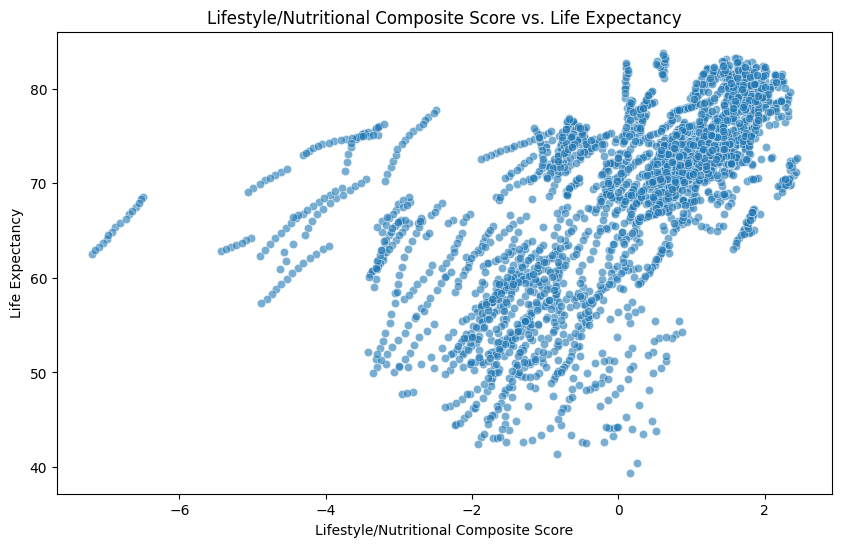

생활/영양 종합 점수와 기대 수명 간의 상관계수: 0.5783930167344044
설명력: 0.68
[[0.37037008 0.46090587 0.5709634  0.56955471]]


In [236]:
nutritional_factors = ['Alcohol_consumption', 'BMI', 'Thinness_ten_nineteen_years_Reversed', 'Thinness_five_nine_years_Reversed']
df_nutritional = df_scaled[nutritional_factors]

pca_nutritional = PCA(n_components=1)
nutritional_score = pca_nutritional.fit_transform(df_nutritional)

df_scaled['LifestyleNutritional_Composite'] = nutritional_score

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled['LifestyleNutritional_Composite'], y=df_scaled['Life_expectancy'], alpha=0.6)
plt.title('Lifestyle/Nutritional Composite Score vs. Life Expectancy')
plt.xlabel('Lifestyle/Nutritional Composite Score')
plt.ylabel('Life Expectancy')
plt.show()

print(f"생활/영양 종합 점수와 기대 수명 간의 상관계수: {df_scaled['LifestyleNutritional_Composite'].corr(df_scaled['Life_expectancy'])}")
print(f"설명력: {pca_nutritional.explained_variance_ratio_[0]:.2f}")
print(pca_nutritional.components_)

#### 4.3 질병 및 예방접종 요인

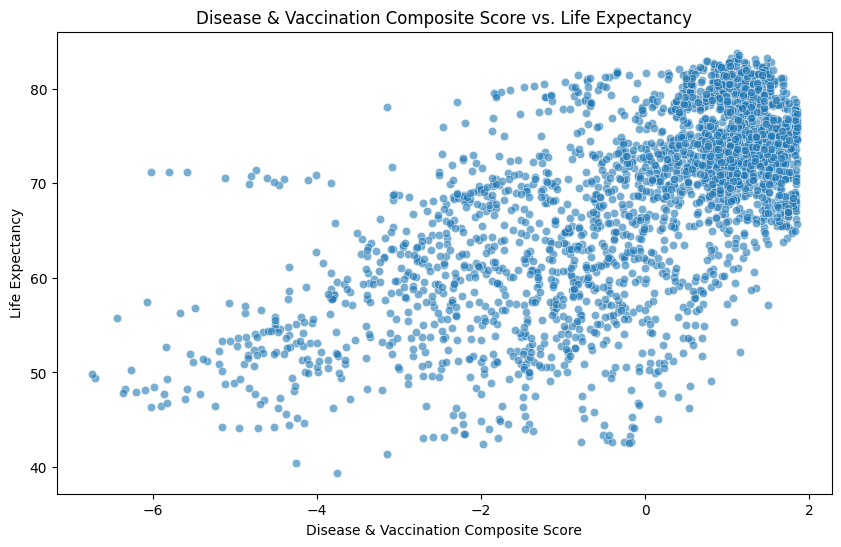

질병/예방접종 종합 점수와 기대수명 간의 상관계수: 0.6661
설명력: 0.60
[[0.12723032 0.48973962 0.54333542 0.54685875 0.38691043]]


In [237]:
disease_vaccination_factors = ['Incidents_HIV_Reversed', 'Hepatitis_B', 'Polio', 'Diphtheria', 'Measles']
df_disease = df_scaled[disease_vaccination_factors]

pca_disease = PCA(n_components=1)
disease_score = pca_disease.fit_transform(df_disease)

df_scaled['DiseaseVaccination_Composite'] = disease_score

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled['DiseaseVaccination_Composite'], y=df_scaled['Life_expectancy'], alpha=0.6)
plt.title('Disease & Vaccination Composite Score vs. Life Expectancy')
plt.xlabel('Disease & Vaccination Composite Score')
plt.ylabel('Life Expectancy')
plt.show()

print(f"질병/예방접종 종합 점수와 기대수명 간의 상관계수: {df_scaled['DiseaseVaccination_Composite'].corr(df_scaled['Life_expectancy']):.4f}")
print(f"설명력: {pca_disease.explained_variance_ratio_[0]:.2f}")
print(pca_disease.components_)

#### 4.4 보건 결과 지표
- 이 부분은 너무 뻔한 결과긴 함.. 걍 뺄까?

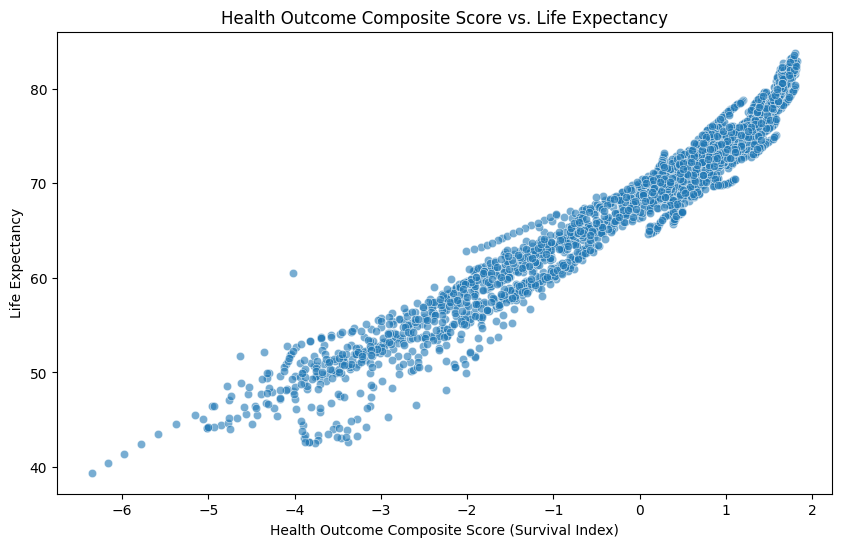

보건 결과 종합 점수와 기대수명 간의 상관계수: 0.9733
설명력: 0.91
[[0.54773202 0.59082509 0.59238108]]


In [238]:
health_outcome_factors = ['Adult_mortality_Reversed', 'Infant_deaths_Reversed', 'Under_five_deaths_Reversed']
df_outcome = df_scaled[health_outcome_factors]

pca_outcome = PCA(n_components=1)
outcome_score = pca_outcome.fit_transform(df_outcome)

df_scaled['HealthOutcome_Composite'] = outcome_score

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled['HealthOutcome_Composite'], y=df_scaled['Life_expectancy'], alpha=0.6)
plt.title('Health Outcome Composite Score vs. Life Expectancy')
plt.xlabel('Health Outcome Composite Score (Survival Index)')
plt.ylabel('Life Expectancy')
plt.show()

print(f"보건 결과 종합 점수와 기대수명 간의 상관계수: {df_scaled['HealthOutcome_Composite'].corr(df_scaled['Life_expectancy']):.4f}")
print(f"설명력: {pca_outcome.explained_variance_ratio_[0]:.2f}")
print(pca_outcome.components_)

---

### 5. 최종 결론 (Conclusion)

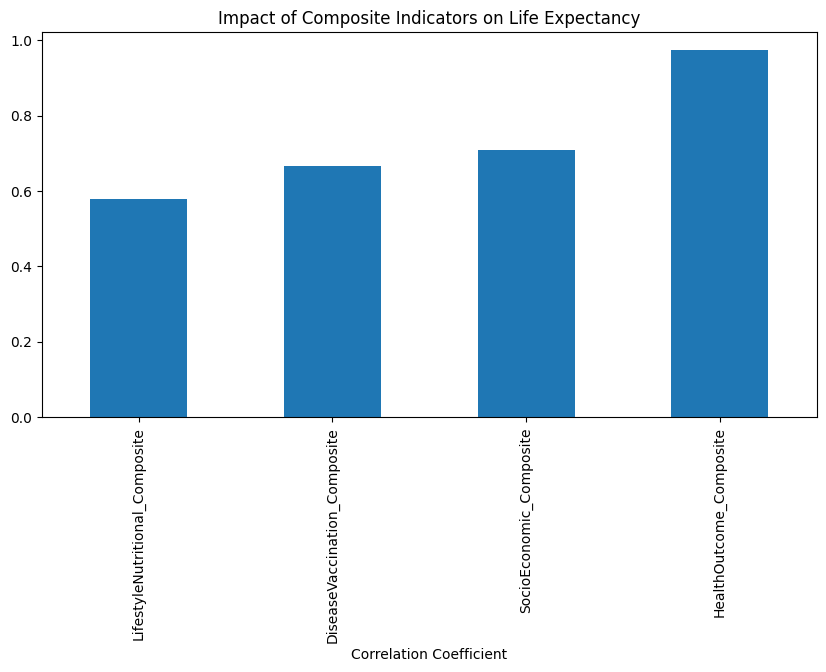

In [239]:
composites = ['SocioEconomic_Composite', 'LifestyleNutritional_Composite', 'DiseaseVaccination_Composite', 'HealthOutcome_Composite']
correlations = df_scaled[composites + ['Life_expectancy']].corr()['Life_expectancy'].drop('Life_expectancy')

plt.figure(figsize=(10, 5))
correlations.sort_values().plot(kind='bar')
plt.title('Impact of Composite Indicators on Life Expectancy')
plt.xlabel('Correlation Coefficient')
plt.show()

# 검토사항
- PCA 타당성
    - pca를 통해서 낸 종합점수가 실제로 각 요인들을 대표할만큼의 타당성을 갖는지 보여줘야함
    - 설명력을 통해서 보여주긴 했으나 검토 필요
    - 아니면 차라리 regression 통해서 보여줘도 괜찮을 듯
- 지역/연도/경제상태/인구수 값은 포함시키지 않았음. 괜찮나?
    - 위 산점도 그래프를 각 지역이나 연도별로 점 색깔을 다르게 해서 보여주는거도 나쁘지 않을 것 같음
- 시각화
    - 다른 그래프를 통해서 더 보여줄 수 있는 사항이 많지 않나?